In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

from fairlearn.metrics import (
    MetricFrame, selection_rate, false_positive_rate, false_negative_rate, true_positive_rate,
    demographic_parity_difference, demographic_parity_ratio,
    equalized_odds_difference, equalized_odds_ratio,
)
from fairlearn.postprocessing import ThresholdOptimizer

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/loans_clean.parquet')

df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df["credit_history_months"] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df["annual_inc"].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

df_val   = df[df["issue_year"] == 2016].copy()
y_val   = df_val['default'].values


print(f"Val loans: {len(df_val):,}")

Val loans: 293,095


In [2]:
df_val_fe = df_val.copy()

def prep_features(df):
    df = df.copy()
    
    redundant = [
        "fico_range_high",
        "funded_amnt",
        "funded_amnt_inv",
        "num_sats",
        "installment",
        "num_rev_tl_bal_gt_0",
    ]

    joint_cols = [c for c in df.columns if c.startswith("sec_app") or c.endswith("_joint")]

    high_cardinality = ["zip_code", "sub_grade"]

    split_cols = ["issue_year"]

    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
        "5 years": 5, "6 years": 6, '7 years': 7, "8 years": 8, "9 years": 9,
        "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
    
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    
    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns]
    )
    
    return df



df_val_fe = prep_features(df_val_fe)
x_val = df_val_fe.drop(columns=['default'])
x_val['term'] = x_val['term'].str.extract(r'(\d+)').astype(int)

numeric_cols = x_val.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = x_val.select_dtypes(include=['object']).columns.tolist()

x_val[numeric_cols] = x_val[numeric_cols].astype('float64')

champion = joblib.load("../models/champion_lgbm.pkl")

class CalibratedChampionClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, preprocessor,  model, calibrator, threshold):
        self.preprocessor = preprocessor
        self.model = model
        self.calibrator = calibrator
        self.threshold = threshold
        self.classes_ = np.array([0, 1])
    def fit(self, X, y):
        return self
    def predict_proba(self,X):
        X_proc = self.preprocessor.transform(X)
        raw = self.model.predict_proba(X_proc)[:, 1]
        cal = self.calibrator.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


champion_clf = CalibratedChampionClassifier(
    preprocessor=champion['preprocessor'],
    model=champion['base_model'],
    calibrator=champion['calibrator'],
    threshold=champion['best_threshold']
)
best_threshold = champion['best_threshold']

y_pred_baseline = champion_clf.predict(x_val)
y_pred_proba    = champion_clf.predict_proba(x_val)[:, 1]

print("Baseline (champion):")
print(f"  Threshold: {best_threshold:.4f}")
print(f"  Selection rate: {y_pred_baseline.mean():.4f}")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Baseline (champion):
  Threshold: 0.1592
  Selection rate: 0.6260


In [3]:
sensitive = pd.DataFrame({
    'addr_state': x_val['addr_state'].values,
    'home_ownership': x_val['home_ownership'].values,
}, index= x_val.index)

sensitive['income_tier'] = pd.qcut(
    x_val['annual_inc'],
    q=4,
    labels=['Q1_low', 'Q2', 'Q3', 'Q4_high']
).astype(str)

def calculate_profit(y_true, y_pred, loan_amounts, gain_rate=0.10, loss_rate=0.50):
    approved = y_pred == 0
    gain = ((approved & (y_true == 0)) * loan_amounts * gain_rate).sum()
    loss = ((approved & (y_true == 1)) * loan_amounts * loss_rate).sum()
    return gain - loss


loan_amounts = x_val['loan_amnt'].values
baseline_profit = calculate_profit(y_val, y_pred_baseline, loan_amounts)
baseline_acc = accuracy_score(y_val, y_pred_baseline)

print(f"Baseline metrics:")
print(f"  Profit:   ${baseline_profit:,.0f}")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"  DP ratio (income):     {demographic_parity_ratio(y_val, y_pred_baseline, sensitive_features=sensitive['income_tier']):.4f}")
print(f"  EO ratio (income):     {equalized_odds_ratio(y_val, y_pred_baseline, sensitive_features=sensitive['income_tier']):.4f}")

Baseline metrics:
  Profit:   $65,566,508
  Accuracy: 0.5369
  DP ratio (income):     0.7160
  EO ratio (income):     0.6866


In [4]:

dp_income_base = demographic_parity_ratio(y_val, y_pred_baseline, sensitive_features=sensitive['income_tier'])
eo_income_base = equalized_odds_ratio(y_val, y_pred_baseline, sensitive_features=sensitive['income_tier'])

to_dp = ThresholdOptimizer(
    estimator=champion_clf,
    constraints='demographic_parity',
    objective='accuracy_score',
    prefit=True,
    predict_method='predict_proba',
)
try:
    to_dp.fit(x_val, y_val, sensitive_features=sensitive['income_tier'])
    y_pred_dp = to_dp.predict(x_val, sensitive_features=sensitive['income_tier'], random_state=42)

    # metrics after mitigation
    profit_after = calculate_profit(y_val, y_pred_dp, loan_amounts)
    acc_after = accuracy_score(y_val, y_pred_dp)
    dp_after =demographic_parity_ratio(y_val, y_pred_dp, sensitive_features = sensitive['income_tier'])
    eo_after = equalized_odds_ratio(y_val, y_pred_dp, sensitive_features = sensitive['income_tier'])

    print("ThresholdOptimizer ran.")
    print(f"\n{'Metric':<25} {'Baseline':>15} {'After mitigation':>20} {'Change':>15}")
    print(f"{'-'*75}")
    print(f"{'Selection rate':<25} {y_pred_baseline.mean():>15.4f} {y_pred_dp.mean():>20.4f} {y_pred_dp.mean() - y_pred_baseline.mean():>+15.4f}")
    print(f"{'Profit':<25} ${baseline_profit:>14,.0f} ${profit_after:>19,.0f} ${profit_after - baseline_profit:>+14,.0f}")
    print(f"{'Accuracy':<25} {baseline_acc:>15.4f} {acc_after:>20.4f} {acc_after - baseline_acc:>+15.4f}")
    print(f"{'DP ratio (income)':<25} {dp_income_base:>15.4f} {dp_after:>20.4f} {dp_after - dp_income_base:>+15.4f}")
    print(f"{'EO ratio (income)':<25} {eo_income_base:>15.4f} {eo_after:>20.4f} {eo_after - eo_income_base:>+15.4f}")

    # Per-group rejection rates after mitigation
    print(f"\nPer-group rejection rate (before -> after):")
    for tier in ['Q1_low', 'Q2', 'Q3', 'Q4_high']:
        mask = (sensitive['income_tier'] == tier).values
        before = y_pred_baseline[mask].mean()
        after = y_pred_dp[mask].mean()
        print(f"  {tier:<10}: {before:.4f} -> {after:.4f}  ({after - before:+.4f})")
except Exception as e:
    print("ThresholdOptimizer failed with error:")
    print(f"  {type(e).__name__}: {e}")
    print("\nFalling back to hand-rolled per-group threshold search.")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ThresholdOptimizer ran.

Metric                           Baseline     After mitigation          Change
---------------------------------------------------------------------------
Selection rate                     0.6260               0.0590         -0.5670
Profit                    $    65,566,508 $       -120,538,188 $  -186,104,695
Accuracy                           0.5369               0.7765         +0.2396
DP ratio (income)                  0.7160               0.9960         +0.2800
EO ratio (income)                  0.6866               0.7950         +0.1085

Per-group rejection rate (before -> after):
  Q1_low    : 0.7244 -> 0.0591  (-0.6653)
  Q2        : 0.6511 -> 0.0590  (-0.5921)
  Q3        : 0.6066 -> 0.0588  (-0.5478)
  Q4_high   : 0.5187 -> 0.0591  (-0.4596)


In [5]:
to_eo = ThresholdOptimizer(
    estimator=champion_clf,
    constraints='equalized_odds',
    objective='accuracy_score',
    prefit=True,
    predict_method='predict_proba',
)

try:
    to_eo.fit(x_val, y_val, sensitive_features=sensitive['income_tier'])
    y_pred_eo = to_eo.predict(x_val, sensitive_features=sensitive['income_tier'], random_state=42)
    
    profit_eo = calculate_profit(y_val, y_pred_eo, loan_amounts)
    acc_eo = accuracy_score(y_val, y_pred_eo)
    dp_eo = demographic_parity_ratio(y_val, y_pred_eo, sensitive_features= sensitive['income_tier'])
    eo_eo = equalized_odds_ratio(y_val, y_pred_eo, sensitive_features=sensitive['income_tier'])
    
    print(f"\nEqualized odds  mitigation on income tier:")
    print(f"\n{'Metric':<25} {'Baseline':>15} {'After EO mit':>20} {'Change':>15}")
    print(f"{'-'*75}")
    print(f"{'Selection rate':<25} {y_pred_baseline.mean():>15.4f} {y_pred_eo.mean():>20.4f} {y_pred_eo.mean() - y_pred_baseline.mean():>+15.4f}")
    print(f"{'Profit':<25} ${baseline_profit:>14,.0f} ${profit_eo:>19,.0f} ${profit_eo - baseline_profit:>+14,.0f}")
    print(f"{'Accuracy':<25} {baseline_acc:>15.4f} {acc_eo:>20.4f} {acc_eo - baseline_acc:>+15.4f}")
    print(f"{'DP ratio (income)':<25} {dp_income_base:>15.4f} {dp_eo:>20.4f} {dp_eo - dp_income_base:>+15.4f}")
    print(f"{'EO ratio (income)':<25} {eo_income_base:>15.4f} {eo_eo:>20.4f} {eo_eo - eo_income_base:>+15.4f}")
    
    print(f"\nPer-group rejection rate (before -> after):")
    for tier in ['Q1_low', 'Q2', 'Q3', 'Q4_high']:
        mask = (sensitive['income_tier'] == tier).values
        before = y_pred_baseline[mask].mean()
        after = y_pred_eo[mask].mean()
        print(f"  {tier:<10}: {before:.4f} -> {after:.4f}  ({after - before:+.4f})")
        
except Exception as e:
    print(f"Failed: {type(e).__name__}: {e}")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Equalized odds  mitigation on income tier:

Metric                           Baseline         After EO mit          Change
---------------------------------------------------------------------------
Selection rate                     0.6260               0.0519         -0.5740
Profit                    $    65,566,508 $       -135,406,985 $  -200,973,492
Accuracy                           0.5369               0.7736         +0.2366
DP ratio (income)                  0.7160               0.8422         +0.1262
EO ratio (income)                  0.6866               0.9694         +0.2828

Per-group rejection rate (before -> after):
  Q1_low    : 0.7244 -> 0.0561  (-0.6683)
  Q2        : 0.6511 -> 0.0527  (-0.5984)
  Q3        : 0.6066 -> 0.0515  (-0.5551)
  Q4_high   : 0.5187 -> 0.0473  (-0.4714)


In [6]:
def find_group_thresholds_for_dp(probs, groups, target_selection_rate):
    """Find per-group thresholds such that each group has the same selection rate."""
    thresholds = {}
    for g in np.unique(groups):
        mask = groups == g
        thresholds[g] = np.quantile(probs[mask], 1 - target_selection_rate)
    return thresholds


def apply_group_thresholds(probs, groups, thresholds):
    """Apply per-group thresholds to get predictions."""
    y_pred = np.zeros(len(probs), dtype=int)
    for g, t in thresholds.items():
        mask = groups == g
        y_pred[mask] = (probs[mask] >= t).astype(int)
    return y_pred


#thresholds that match the baseline overall selection rate
target_sel_rate = y_pred_baseline.mean()  
group_thresholds = find_group_thresholds_for_dp(
    y_pred_proba,
    sensitive['income_tier'].values,
    target_sel_rate
)

print(f"Target selection rate: {target_sel_rate:.4f}\n")
print("Group-specific thresholds for demographic parity:")
for g in ['Q1_low', 'Q2', 'Q3', 'Q4_high']:
    t = group_thresholds[g]
    direction = "lower" if t < best_threshold else "higher"
    diff = t - best_threshold
    print(f"  {g:<10}: {t:.4f}  ({direction} than baseline {best_threshold:.4f}, diff {diff:+.4f})")

y_pred_dp_hand = apply_group_thresholds(
    y_pred_proba,
    sensitive['income_tier'].values,
    group_thresholds
)

profit_hand = calculate_profit(y_val, y_pred_dp_hand, loan_amounts)
acc_hand = accuracy_score(y_val, y_pred_dp_hand)
dp_hand = demographic_parity_ratio(y_val, y_pred_dp_hand, sensitive_features=sensitive['income_tier'])
eo_hand = equalized_odds_ratio(y_val, y_pred_dp_hand, sensitive_features=sensitive['income_tier'])

print(f"\nHand-rolled DP mitigation (preserving overall selection rate):")
print(f"\n{'Metric':<25} {'Baseline':>15} {'After mitigation':>20} {'Change':>15}")
print(f"{'-'*75}")
print(f"{'Selection rate':<25} {y_pred_baseline.mean():>15.4f} {y_pred_dp_hand.mean():>20.4f} {y_pred_dp_hand.mean() - y_pred_baseline.mean():>+15.4f}")
print(f"{'Profit':<25} ${baseline_profit:>14,.0f} ${profit_hand:>19,.0f} ${profit_hand - baseline_profit:>+14,.0f}")
print(f"{'Accuracy':<25} {baseline_acc:>15.4f} {acc_hand:>20.4f} {acc_hand - baseline_acc:>+15.4f}")
print(f"{'DP ratio (income)':<25} {dp_income_base:>15.4f} {dp_hand:>20.4f} {dp_hand - dp_income_base:>+15.4f}")
print(f"{'EO ratio (income)':<25} {eo_income_base:>15.4f} {eo_hand:>20.4f} {eo_hand - eo_income_base:>+15.4f}")

print(f"\nPer-group rejection rate (before -> after):")
for tier in ['Q1_low', 'Q2', 'Q3', 'Q4_high']:
    mask = (sensitive['income_tier'] == tier).values
    before = y_pred_baseline[mask].mean()
    after = y_pred_dp_hand[mask].mean()
    print(f"  {tier:<10}: {before:.4f} -> {after:.4f}  ({after - before:+.4f})")

Target selection rate: 0.6260

Group-specific thresholds for demographic parity:
  Q1_low    : 0.1917  (higher than baseline 0.1592, diff +0.0325)
  Q2        : 0.1758  (higher than baseline 0.1592, diff +0.0165)
  Q3        : 0.1470  (lower than baseline 0.1592, diff -0.0123)
  Q4_high   : 0.1244  (lower than baseline 0.1592, diff -0.0348)

Hand-rolled DP mitigation (preserving overall selection rate):

Metric                           Baseline     After mitigation          Change
---------------------------------------------------------------------------
Selection rate                     0.6260               0.6466         +0.0206
Profit                    $    65,566,508 $         61,229,478 $    -4,337,030
Accuracy                           0.5369               0.5198         -0.0171
DP ratio (income)                  0.7160               0.9515         +0.2355
EO ratio (income)                  0.6866               0.9317         +0.2451

Per-group rejection rate (before -> after

In [7]:
target_rates = np.linspace(0.40, 0.85, 30)
pareto_results = []

for target_rate in target_rates:
    thresholds = find_group_thresholds_for_dp(
        y_pred_proba,
        sensitive['income_tier'].values,
        target_rate
    )
    y_pred_t = apply_group_thresholds(
        y_pred_proba,
        sensitive['income_tier'].values,
        thresholds
    )
    
    pareto_results.append({
        'target_sel_rate': target_rate,
        'actual_sel_rate': y_pred_t.mean(),
        'profit': calculate_profit(y_val, y_pred_t, loan_amounts),
        'accuracy': accuracy_score(y_val, y_pred_t),
        'dp_ratio': demographic_parity_ratio(y_val, y_pred_t, sensitive_features=sensitive['income_tier']),
        'eo_ratio': equalized_odds_ratio(y_val, y_pred_t, sensitive_features=sensitive['income_tier']),
    })

pareto_df = pd.DataFrame(pareto_results)
print(pareto_df.round(4).to_string(index=False))

 target_sel_rate  actual_sel_rate     profit  accuracy  dp_ratio  eo_ratio
          0.4000           0.4221 51183207.5    0.6569    0.9336    0.9257
          0.4155           0.4290 52058810.0    0.6529    0.9593    0.9257
          0.4310           0.4491 53979222.5    0.6413    0.9157    0.8831
          0.4466           0.4632 55759142.5    0.6340    0.9575    0.9194
          0.4621           0.4722 55684715.0    0.6280    0.9502    0.8869
          0.4776           0.4867 57333190.0    0.6200    0.9691    0.9091
          0.4931           0.5079 59760602.5    0.6088    0.9254    0.9243
          0.5086           0.5334 61568047.5    0.5931    0.9564    0.9324
          0.5241           0.5371 61384395.0    0.5906    0.9838    0.9233
          0.5397           0.5493 60816027.5    0.5822    0.9457    0.9002
          0.5552           0.5757 62379410.0    0.5665    0.9733    0.9275
          0.5707           0.5852 63170020.0    0.5614    0.9421    0.9495
          0.5862         

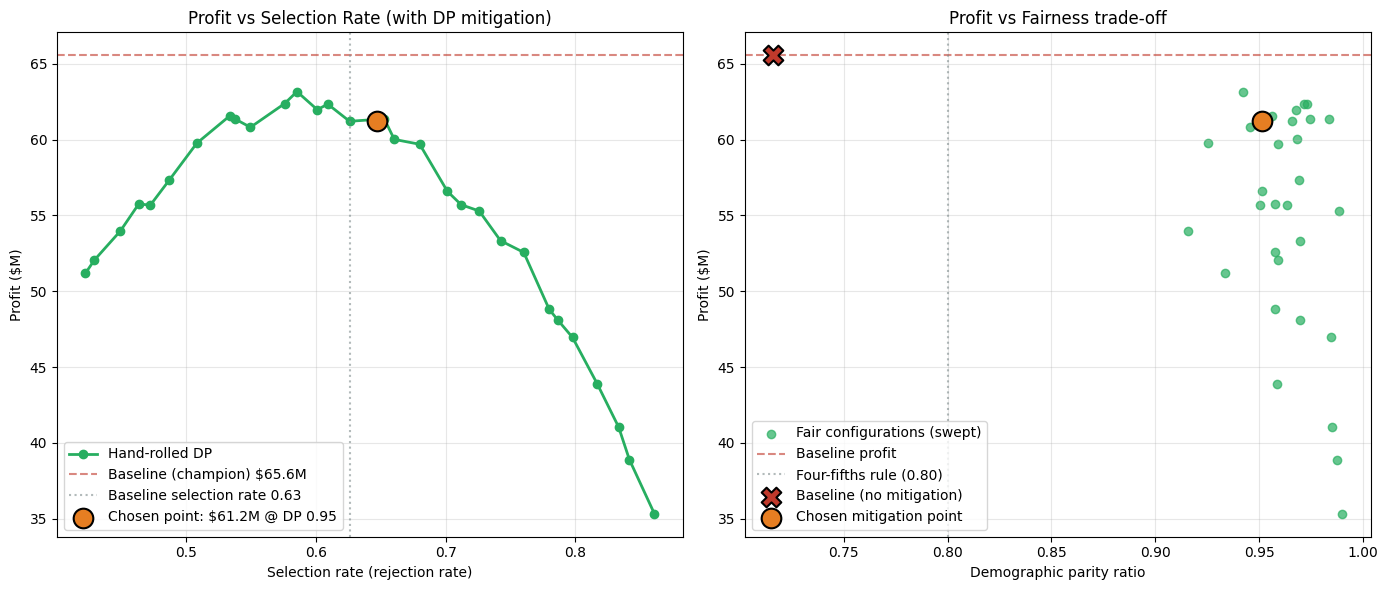

In [8]:
fig, axes = plt.subplots(1, 2, figsize= (14, 6))

#Profit vs Selection Rate
axes[0].plot(pareto_df['actual_sel_rate'], pareto_df['profit'] / 1e6,
             marker='o', linewidth=2, color='#27ae60', label='Hand-rolled DP')
axes[0].axhline(baseline_profit / 1e6, color='#c0392b', linestyle='--', alpha=0.6,
                label=f'Baseline (champion) ${baseline_profit/1e6:.1f}M')
axes[0].axvline(y_pred_baseline.mean(), color='#7f8c8d', linestyle=':', alpha=0.6,
                label=f'Baseline selection rate {y_pred_baseline.mean():.2f}')
axes[0].scatter([y_pred_dp_hand.mean()], [profit_hand / 1e6],
                s=200, color='#e67e22', zorder=5, edgecolors='black', linewidth=1.5,
                label=f'Chosen point: ${profit_hand/1e6:.1f}M @ DP {dp_hand:.2f}')
axes[0].set_xlabel("Selection rate (rejection rate)")
axes[0].set_ylabel("Profit ($M)")
axes[0].set_title("Profit vs Selection Rate (with DP mitigation)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Profit vs Fairness
axes[1].scatter(pareto_df['dp_ratio'], pareto_df['profit'] / 1e6,
                color='#27ae60', alpha=0.7, label='Fair configurations (swept)')
axes[1].axhline(baseline_profit / 1e6, color='#c0392b', linestyle='--', alpha=0.6,
                label='Baseline profit')
axes[1].axvline(0.80, color='#7f8c8d', linestyle=':', alpha=0.6,
                label='Four-fifths rule (0.80)')
axes[1].scatter([dp_income_base], [baseline_profit / 1e6],
                s=200, color='#c0392b', marker='X', zorder=5,
                edgecolors='black', linewidth=1.5, label='Baseline (no mitigation)')
axes[1].scatter([dp_hand], [profit_hand / 1e6],
                s=200, color='#e67e22', zorder=5, edgecolors='black', linewidth=1.5,
                label='Chosen mitigation point')
axes[1].set_xlabel("Demographic parity ratio")
axes[1].set_ylabel("Profit ($M)")
axes[1].set_title("Profit vs Fairness trade-off")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/fairness_mitigation_tradeoff.png", bbox_inches='tight', dpi=150)
plt.show()

In [9]:
home_mask = (sensitive['home_ownership'] != 'ANY').values

home_thresholds = find_group_thresholds_for_dp(
    y_pred_proba[home_mask],
    sensitive['home_ownership'].values[home_mask],
    target_sel_rate
)

print(f"Per-group thresholds for home_ownership DP:")
for g in ['MORTGAGE', 'OWN', 'RENT']:
    t = home_thresholds[g]
    direction = "lower" if t < best_threshold else "higher"
    diff = t - best_threshold
    print(f"  {g:<10}: {t:.4f}  ({direction} than baseline {best_threshold:.4f}, diff {diff:+.4f})")

y_pred_home = y_pred_baseline.copy()
y_pred_home[home_mask] = apply_group_thresholds(
    y_pred_proba[home_mask],
    sensitive['home_ownership'].values[home_mask],
    home_thresholds
)

profit_home = calculate_profit(y_val, y_pred_home, loan_amounts)
acc_home = accuracy_score(y_val, y_pred_home)
dp_home = demographic_parity_ratio(y_val[home_mask], y_pred_home[home_mask], sensitive_features=sensitive['home_ownership'].values[home_mask])
eo_home = equalized_odds_ratio(y_val[home_mask], y_pred_home[home_mask], sensitive_features=sensitive['home_ownership'].values[home_mask])
dp_home_base = demographic_parity_ratio(y_val[home_mask], y_pred_baseline[home_mask],sensitive_features=sensitive['home_ownership'].values[home_mask])
eo_home_base = equalized_odds_ratio(y_val[home_mask], y_pred_baseline[home_mask], sensitive_features=sensitive['home_ownership'].values[home_mask])

print(f"\nHome ownership DP mitigation:")
print(f"  Selection rate: {y_pred_home.mean():.4f}")
print(f"  Profit:         ${profit_home:,.0f}  (change: ${profit_home - baseline_profit:+,.0f})")
print(f"  Accuracy:       {acc_home:.4f}")
print(f"  DP ratio:       {dp_home_base:.4f} -> {dp_home:.4f}")
print(f"  EO ratio:       {eo_home_base:.4f} -> {eo_home:.4f}")

Per-group thresholds for home_ownership DP:
  MORTGAGE  : 0.1444  (lower than baseline 0.1592, diff -0.0149)
  OWN       : 0.1667  (higher than baseline 0.1592, diff +0.0074)
  RENT      : 0.1917  (higher than baseline 0.1592, diff +0.0325)

Home ownership DP mitigation:
  Selection rate: 0.6426
  Profit:         $61,332,570  (change: $-4,233,938)
  Accuracy:       0.5228
  DP ratio:       0.7766 -> 0.9823
  EO ratio:       0.7637 -> 0.9727


In [10]:
sensitive['income_x_home'] = sensitive['income_tier'].astype(str) + ' | ' + sensitive['home_ownership'].astype(str)


inter_thresholds = find_group_thresholds_for_dp(
    y_pred_proba[home_mask],
    sensitive['income_x_home'].values[home_mask],
    target_sel_rate
)

print(f"Per-group thresholds for intersectional DP (12 groups):")
for g in sorted(inter_thresholds.keys()):
    t = inter_thresholds[g]
    print(f"  {g:<22}: {t:.4f}")


y_pred_inter = y_pred_baseline.copy()
y_pred_inter[home_mask] = apply_group_thresholds(
    y_pred_proba[home_mask],
    sensitive['income_x_home'].values[home_mask],
    inter_thresholds
)

profit_inter = calculate_profit(y_val, y_pred_inter, loan_amounts)
acc_inter = accuracy_score(y_val, y_pred_inter)
dp_inter = demographic_parity_ratio(y_val[home_mask], y_pred_inter[home_mask], sensitive_features=sensitive['income_x_home'].values[home_mask])
eo_inter = equalized_odds_ratio(y_val[home_mask], y_pred_inter[home_mask], sensitive_features=sensitive['income_x_home'].values[home_mask])
dp_inter_base = demographic_parity_ratio(y_val[home_mask], y_pred_baseline[home_mask],sensitive_features=sensitive['income_x_home'].values[home_mask])
eo_inter_base  = equalized_odds_ratio(y_val[home_mask], y_pred_baseline[home_mask], sensitive_features=sensitive['income_x_home'].values[home_mask])

print(f"\nIntersectional (income × home) DP mitigation:")
print(f"  Selection rate: {y_pred_inter.mean():.4f}")
print(f"  Profit:         ${profit_inter:,.0f}  (change: ${profit_inter - baseline_profit:+,.0f})")
print(f"  Accuracy:       {acc_inter:.4f}")
print(f"  DP ratio:       {dp_inter_base:.4f} -> {dp_inter:.4f}")
print(f"  EO ratio:       {eo_inter_base:.4f} -> {eo_inter:.4f}")

Per-group thresholds for intersectional DP (12 groups):
  Q1_low | MORTGAGE     : 0.1667
  Q1_low | OWN          : 0.1917
  Q1_low | RENT         : 0.2088
  Q2 | MORTGAGE         : 0.1470
  Q2 | OWN              : 0.1804
  Q2 | RENT             : 0.1917
  Q3 | MORTGAGE         : 0.1444
  Q3 | OWN              : 0.1667
  Q3 | RENT             : 0.1804
  Q4_high | MORTGAGE    : 0.1171
  Q4_high | OWN         : 0.1255
  Q4_high | RENT        : 0.1667

Intersectional (income × home) DP mitigation:
  Selection rate: 0.6428
  Profit:         $59,842,495  (change: $-5,724,012)
  Accuracy:       0.5211
  DP ratio:       0.6141 -> 0.9482
  EO ratio:       0.5853 -> 0.9290


In [11]:
results = pd.DataFrame([
    {'Approach': 'Baseline (champion)', 'Profit ($M)': baseline_profit/1e6, 'Accuracy': baseline_acc, 'DP income': dp_income_base, 'EO income': eo_income_base, 'Note': 'Profit-optimized single threshold'},
    {'Approach': 'Fairlearn DP (income)', 'Profit ($M)': profit_after/1e6, 'Accuracy': acc_after, 'DP income': dp_after, 'EO income': eo_after, 'Note': 'Approves ~94%, profit to -$120M'},
    {'Approach': 'Fairlearn EO (income)', 'Profit ($M)': profit_eo/1e6, 'Accuracy': acc_eo, 'DP income': dp_eo, 'EO income': eo_eo, 'Note': 'Accuracy objective, profit-blind'},
    {'Approach': 'Hand-rolled DP (income)', 'Profit ($M)': profit_hand/1e6, 'Accuracy': acc_hand, 'DP income': dp_hand, 'EO income': eo_hand, 'Note': 'Preserves overall volume'},
    {'Approach': 'Hand-rolled DP (home)', 'Profit ($M)': profit_home/1e6, 'Accuracy': acc_home, 'DP income': '-', 'EO income': '-', 'Note': f'DP home {dp_home:.3f}, EO home {eo_home:.3f}'},
    {'Approach': 'Hand-rolled DP (intersectional)', 'Profit ($M)': profit_inter/1e6, 'Accuracy': acc_inter, 'DP income': '-', 'EO income': '-', 'Note': f'DP inter {dp_inter:.3f}, EO inter {eo_inter:.3f}'},
])
print(results.to_string(index=False))

                       Approach  Profit ($M)  Accuracy DP income EO income                              Note
            Baseline (champion)    65.566508  0.536925  0.716035  0.686557 Profit-optimized single threshold
          Fairlearn DP (income)  -120.538188  0.776520  0.996016  0.795032   Approves ~94%, profit to -$120M
          Fairlearn EO (income)  -135.406985  0.773568  0.842233  0.969365  Accuracy objective, profit-blind
        Hand-rolled DP (income)    61.229478  0.519825  0.951496  0.931671          Preserves overall volume
          Hand-rolled DP (home)    61.332570  0.522807         -         -      DP home 0.982, EO home 0.973
Hand-rolled DP (intersectional)    59.842495  0.521131         -         -    DP inter 0.948, EO inter 0.929
